<a href="https://colab.research.google.com/github/profpranjali-del/PJ/blob/main/Topic_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total documents: 76

========== TOPIC KEYWORDS ==========


TOPIC 0
['framework', 'collaboration', 'experience', 'data', 'students', 'developer', 'productivity', 'engineers', 'technology', 'industry', 'engineering', 'generative', 'adoption', 'developers', 'development']

TOPIC 1
['benchmarks', 'empirical', 'based code', 'generated code', 'prompt', 'programming languages', 'generated', 'tasks', 'programming', 'performance', 'languages', 'non', 'generation', 'code generation', 'code']

TOPIC 2
['efficiency', 'application', 'process', 'utilizing', 'quality', 'precision', 'gpt', 'experts', 'prompts', 'engineering', 'prompt', 'development', 'structured', 'requirements engineering', 'requirements']

TOPIC 3
['integration', 'development life', 'sdlc security', 'secure', 'threat', 'agentic', 'development lifecycle', 'lifecycle', 'development', 'collaboration', 'cybersecurity', 'human', 'roles', 'security', 'sdlc']

TOPIC 4
['represent', 'tester', 'agentic', 'scalable', 'engineering process', '

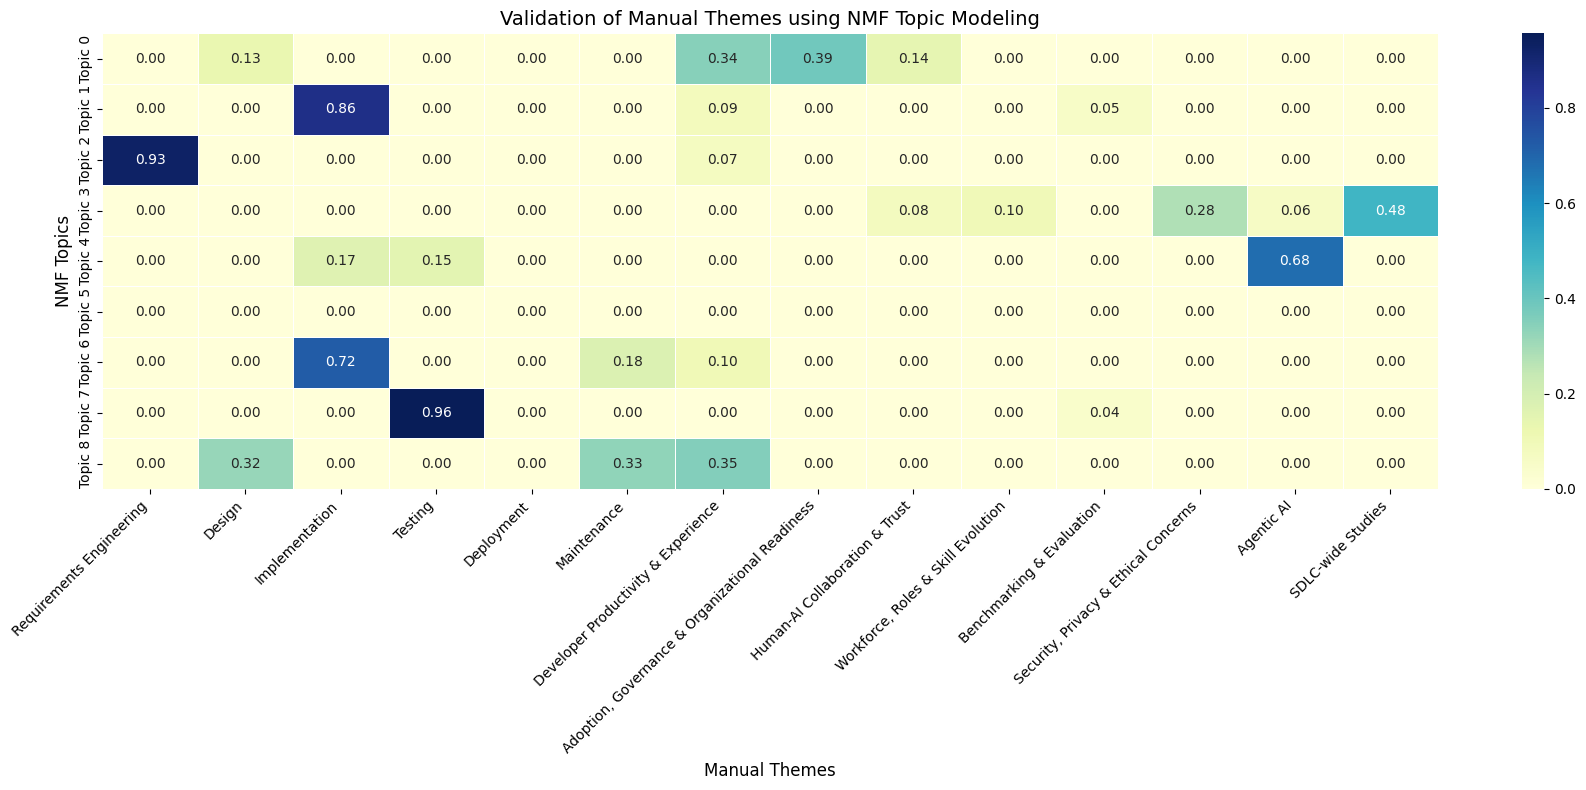


Files Saved:
1. NMF_Theme_Validation.png
2. NMF_Topic_Theme_Alignment.xlsx
3. Document_Topic_Assignment.xlsx

Review printed topic keywords before final interpretation.


In [2]:
# ==========================================

# NMF VALIDATION OF MANUAL THEMES

# SDLC + CROSS-CUTTING THEMES

# ==========================================

!pip install scikit-learn pandas numpy nltk seaborn openpyxl

import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from nltk.corpus import stopwords

nltk.download('stopwords')

# ==========================================

# LOAD DATA

# ==========================================

df = pd.read_excel("/content/SDLC_Review_Title_Abstract_Keywords.xlsx")

text_cols = ["Title", "Abstract", "Keywords"]

df["Combined"] = (
df[text_cols]
.fillna("")
.astype(str)
.agg(" ".join, axis=1)
)

docs = df["Combined"].tolist()

print("Total documents:", len(docs))

# ==========================================

# PREPROCESSING

# ==========================================

custom_stopwords = set(stopwords.words("english"))

custom_stopwords.update([
"software",
"system",
"systems",
"study",
"studies",
"paper",
"papers",
"approach",
"analysis",
"model",
"models",
"artificial",
"intelligence",
"ai",
"genai",
"llm",
"llms",
"large",
"language",
"using",
"used",
"use",
"tool",
"tools",
"chatgpt",
"copilot",
"method",
"methods"
])

def preprocess(text):

    text = text.lower()

    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    return text


processed_docs = [
preprocess(doc)
for doc in docs
]

# ==========================================

# TF-IDF

# ==========================================

tfidf = TfidfVectorizer(
max_df=0.85,
min_df=2,
stop_words=list(custom_stopwords),
ngram_range=(1,2)
)

X = tfidf.fit_transform(processed_docs)

terms = tfidf.get_feature_names_out()

# ==========================================

# NMF

# ==========================================

n_topics = 9

nmf = NMF(
n_components=n_topics,
random_state=42,
max_iter=1000,
init="nndsvda",
alpha_W=0.0001,
alpha_H=0.0001,
l1_ratio=0.5
)

W = nmf.fit_transform(X)
H = nmf.components_

# ==========================================

# DOCUMENT TOPIC ASSIGNMENT

# ==========================================

topic_labels = W.argmax(axis=1)

df["nmf_topic"] = topic_labels

# ==========================================

# INSPECT TOPIC KEYWORDS

# ==========================================

print("\n========== TOPIC KEYWORDS ==========\n")

for topic_idx, topic in enumerate(H):

    top_words = [
        terms[i]
        for i in topic.argsort()[-15:]
    ]

    print(f"\nTOPIC {topic_idx}")
    print(top_words)


# ==========================================

# MANUAL THEMES

# ==========================================

manual_themes = {

    # ======================================
    # SDLC THEMES
    # ======================================

    "Requirements Engineering": [
        "requirement",
        "requirements",
        "requirements engineering",
        "elicitation",
        "requirements elicitation",
        "user story",
        "specification",
        "traceability",
        "ambiguity",
        "inconsistency",
        "incompleteness",
        "prompting",
        "structured prompt"
    ],

    "Design": [
        "design",
        "software design",
        "architecture",
        "architectural",
        "architect",
        "uml",
        "class diagram",
        "modeling",
        "design decision",
        "prototyping",
        "innovation"
    ],

    "Implementation": [
        "implementation",
        "coding",
        "programming",
        "code",
        "code generation",
        "source code",
        "completion",
        "documentation",
        "program synthesis"
    ],

    "Testing": [
        "testing",
        "test",
        "unit test",
        "test generation",
        "test automation",
        "coverage",
        "verification",
        "validation",
        "debugging"
    ],

    "Deployment": [
        "deployment",
        "deploy",
        "release",
        "production",
        "pipeline",
        "continuous integration",
        "continuous delivery",
        "devops",
        "delivery"
    ],

    "Maintenance": [
        "maintenance",
        "maintainability",
        "repair",
        "program repair",
        "bug",
        "bug fixing",
        "refactoring",
        "code refinement",
        "code change",
        "technical debt",
        "software evolution",
        "legacy"
    ],

    # ======================================
    # CROSS-CUTTING THEMES
    # ======================================

    "Developer Productivity & Experience": [
        "productivity",
        "efficient",
        "efficiency",
        "performance",
        "developer experience",
        "experience",
        "mental workload",
        "workflow",
        "time saving",
        "effort",
        "effectiveness",
        "developer productivity",
        "documentation review"
    ],

    "Adoption, Governance & Organizational Readiness": [
        "adoption",
        "adopt",
        "acceptance",
        "organizational",
        "organization",
        "readiness",
        "governance",
        "policy",
        "compliance",
        "maturity",
        "management",
        "strategy",
        "organizational adoption",
        "organizational impact"
    ],

    "Human-AI Collaboration & Trust": [
        "collaboration",
        "human ai",
        "human ai collaboration",
        "pair programming",
        "assistant",
        "interaction",
        "trust",
        "confidence",
        "belief",
        "perception",
        "transparency",
        "developer interaction",
        "co creation",
        "explainability"
    ],

    "Workforce, Roles & Skill Evolution": [
        "workforce",
        "role",
        "roles",
        "skill",
        "skills",
        "career",
        "job",
        "persona",
        "future workforce",
        "software engineer",
        "developer role",
        "workplace"
    ],

    "Benchmarking & Evaluation": [
        "benchmark",
        "benchmarking",
        "evaluation",
        "performance evaluation",
        "comparison",
        "assessment",
        "metrics",
        "hyperparameter",
        "reliability",
        "similarity",
        "code intelligence"
    ],

    "Security, Privacy & Ethical Concerns": [
        "security",
        "privacy",
        "ethical",
        "ethics",
        "bias",
        "risk",
        "vulnerability",
        "cybersecurity",
        "attack",
        "copyright",
        "licensing"
    ],

    # IMPORTANT:
    # Agentic AI is intentionally narrow
    # because it is an emerging theme
    # represented by very few studies

    "Agentic AI": [
        "agentic",
        "multi agent",
        "swe agent",
        "autonomous software engineering",
        "agent computer interface"
    ],

    "SDLC-wide Studies": [
        "software development lifecycle",
        "sdlc",
        "lifecycle",
        "life cycle",
        "development process",
        "across phases",
        "end to end"
    ]

}

# ==========================================

# WEIGHTED TOPIC-THEME ALIGNMENT

# ==========================================

theme_list = list(manual_themes.keys())

score_matrix = np.zeros(
(n_topics, len(theme_list))
)

for t_idx, topic in enumerate(H):

    top_indices = topic.argsort()[-20:]

    for j, theme in enumerate(theme_list):

        score = 0

        for idx in top_indices:

            term = terms[idx]
            weight = topic[idx]

            if any(
                kw.lower() in term.lower()
                for kw in manual_themes[theme]
            ):
                score += weight

        score_matrix[t_idx, j] = score


# ==========================================

# NORMALIZE ROWS

# ==========================================

row_sums = score_matrix.sum(
axis=1,
keepdims=True
)

row_sums[row_sums == 0] = 1

score_matrix = score_matrix / row_sums

heatmap_df = pd.DataFrame(
score_matrix,
index=[f"Topic {i}" for i in range(n_topics)],
columns=theme_list
)

# ==========================================

# SAVE TOPIC-THEME MATRIX

# ==========================================

heatmap_df.to_excel(
"NMF_Topic_Theme_Alignment.xlsx"
)

# ==========================================

# HEATMAP

# ==========================================

plt.figure(figsize=(18,8))

sns.heatmap(
heatmap_df,
annot=True,
cmap="YlGnBu",
fmt=".2f",
linewidths=0.5
)

plt.title(
"Validation of Manual Themes using NMF Topic Modeling",
fontsize=14
)

plt.xlabel(
"Manual Themes",
fontsize=12
)

plt.ylabel(
"NMF Topics",
fontsize=12
)

plt.xticks(
rotation=45,
ha="right"
)

plt.tight_layout()

plt.savefig(
"NMF_Theme_Validation.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

# ==========================================

# EXPORT DOCUMENT TOPICS

# ==========================================

df.to_excel(
"Document_Topic_Assignment.xlsx",
index=False
)

print("\nFiles Saved:")
print("1. NMF_Theme_Validation.png")
print("2. NMF_Topic_Theme_Alignment.xlsx")
print("3. Document_Topic_Assignment.xlsx")
print("\nReview printed topic keywords before final interpretation.")
